# 0-1 Knapsack: Packing a Backpack

A classic illustration of the binary knapsack problem {cite:p}`Wolsey1998,Nemhauser1988`: a hiker has a collection of items, each with a *value* and a *weight*, and a backpack with a hard weight limit. Which subset of items maximizes total value without exceeding the capacity?

Adapted from https://www.linkedin.com/feed/update/urn:li:activity:7462498505203523585/.

## Problem

We have 12 candidate items and a backpack capacity of $W = 23$.

| item         | value $v_i$ | weight $w_i$ |
|--------------|-------------|--------------|
| laptop       | 25          | 6            |
| water bottle | 4           | 2            |
| tent         | 50          | 11           |
| sleeping bag | 14          | 5            |
| flashlight   | 6           | 1            |
| first aid kit| 10          | 3            |
| stove        | 12          | 4            |
| jacket       | 11          | 4            |
| map          | 5           | 1            |
| camera       | 16          | 3            |
| knife        | 8           | 1            |
| compass      | 7           | 1            |

## Mathematical formulation

Let $\mathcal{I}$ be the set of items and let $y_i \in \{0, 1\}$ indicate whether item $i$ is packed.

$$
\begin{aligned}
\max_{y} \quad & \sum_{i \in \mathcal{I}} v_i\, y_i & \text{(total value)} \\
\text{s.t.} \quad & \sum_{i \in \mathcal{I}} w_i\, y_i \le W & \text{(capacity)} \\
& y_i \in \{0, 1\} & \forall i \in \mathcal{I}
\end{aligned}
$$

This is a 0-1 integer linear program; with $n = 12$ items the full search space is only $2^{12} = 4096$ combinations, but the formulation and `discopt` workflow generalize directly to instances with thousands of items, where branch-and-bound {cite:p}`Land1960` becomes essential.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import discopt.modeling as dm
import numpy as np

## 1. Problem data

We keep names, values, and weights aligned by index.

In [2]:
items = [
    "laptop",
    "water bottle",
    "tent",
    "sleeping bag",
    "flashlight",
    "first aid kit",
    "stove",
    "jacket",
    "map",
    "camera",
    "knife",
    "compass",
]
values = np.array([25, 4, 50, 14, 6, 10, 12, 11, 5, 16, 8, 7])
weights = np.array([6, 2, 11, 5, 1, 3, 4, 4, 1, 3, 1, 1])
capacity = 23
n = len(items)

print(f"{n} items, capacity = {capacity}")
print(f"Total weight if everything packed: {weights.sum()} (over capacity by {weights.sum() - capacity})")
print(f"Max possible value (all items):    {values.sum()}")

12 items, capacity = 23
Total weight if everything packed: 42 (over capacity by 19)
Max possible value (all items):    168


## 2. Build the model

`m.binary("y", shape=(n,))` creates the vector of $\{0,1\}$ decision variables. The objective and capacity constraint are linear sums over the item index.

In [3]:
m = dm.Model("backpack")

y = m.binary("y", shape=(n,))

m.maximize(dm.sum(lambda i: values[i] * y[i], over=range(n)))

m.subject_to(
    dm.sum(lambda i: weights[i] * y[i], over=range(n)) <= capacity,
    name="capacity",
)

print(m.summary())

Model: backpack
  Variables: 12 (0 continuous, 12 integer/binary)
  Constraints: 1
  Objective: maximize Σ[12 terms]
  Parameters: 0


## 3. Solve

`Model.solve()` runs branch-and-bound. For a 12-variable binary problem the answer is essentially instant; the LP relaxation of knapsack is famously tight, so very few nodes are explored.

In [4]:
result = m.solve()

print(f"Status:    {result.status}")
print(f"Value:     {result.objective:.1f}")
print(f"Gap:       {result.gap}")
print(f"Nodes:     {result.node_count}")
print(f"Time:      {result.wall_time:.3f}s")

Status:    optimal
Value:     112.0
Gap:       0.0
Nodes:     1
Time:      0.040s


## 4. Read the packed knapsack

In [5]:
packed = result.value(y)

rows = []
tot_v, tot_w = 0, 0
for i in range(n):
    if packed[i] > 0.5:
        rows.append((items[i], int(values[i]), int(weights[i])))
        tot_v += int(values[i])
        tot_w += int(weights[i])

print(f"{'item':<15} {'value':>6} {'weight':>7}")
print("-" * 32)
for name, v, w in rows:
    print(f"{name:<15} {v:>6} {w:>7}")
print("-" * 32)
print(f"{'TOTAL':<15} {tot_v:>6} {tot_w:>7}  (capacity {capacity})")

item             value  weight
--------------------------------
laptop              25       6
tent                50      11
flashlight           6       1
camera              16       3
knife                8       1
compass              7       1
--------------------------------
TOTAL              112      23  (capacity 23)


## 5. The LP relaxation and an upper bound

Dropping integrality gives the LP relaxation, whose optimum is an upper bound on the MILP. Dantzig's classical observation for the *continuous* knapsack is that you should pack items in decreasing order of value-to-weight ratio and split the last item that does not fully fit. Let us compare that bound to the integer optimum.

In [6]:
order = np.argsort(-values / weights)
remaining = capacity
lp_value = 0.0
for i in order:
    if weights[i] <= remaining:
        lp_value += values[i]
        remaining -= weights[i]
    else:
        lp_value += values[i] * (remaining / weights[i])
        remaining = 0
        break

print(f"Greedy LP-relaxation upper bound: {lp_value:.3f}")
print(f"Integer optimum from discopt:     {result.objective:.3f}")
print(f"Integrality gap:                  {lp_value - result.objective:.3f}")

Greedy LP-relaxation upper bound: 112.833
Integer optimum from discopt:     112.000
Integrality gap:                  0.833


## 6. Sensitivity: how does the optimum change with capacity?

Re-solving the model for a sweep of capacities traces out the *value-vs-capacity* curve. This is a discrete, piecewise-constant function that jumps each time a new item becomes affordable.

In [7]:
def best_value(cap):
    mdl = dm.Model(f"backpack_W{cap}")
    yv = mdl.binary("y", shape=(n,))
    mdl.maximize(dm.sum(lambda i: values[i] * yv[i], over=range(n)))
    mdl.subject_to(dm.sum(lambda i: weights[i] * yv[i], over=range(n)) <= cap)
    return mdl.solve().objective


caps = list(range(0, int(weights.sum()) + 1))
best = [best_value(c) for c in caps]

print(f"{'capacity':>8} {'best value':>11}")
for c, v in zip(caps, best):
    marker = "  <-- our backpack" if c == capacity else ""
    print(f"{c:>8} {v:>11.0f}{marker}")

capacity  best value
       0          -0
       1           8
       2          15
       3          21
       4          26
       5          31
       6          37
       7          42
       8          42
       9          47
      10          52
      11          56
      12          62
      13          67
      14          71
      15          76
      16          81
      17          87
      18          92
      19          92
      20          97
      21         102
      22         106
      23         112  <-- our backpack
      24         117
      25         117
      26         122
      27         127
      28         129
      29         131
      30         134
      31         139
      32         141
      33         143
      34         145
      35         150
      36         153
      37         154
      38         157
      39         159
      40         164
      41         164
      42         168


Plot the curve.

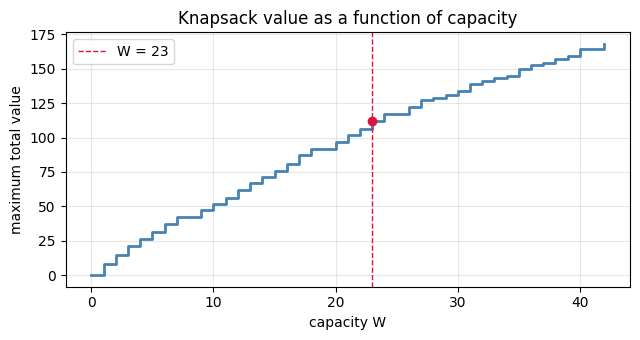

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.step(caps, best, where="post", color="steelblue", lw=2)
ax.axvline(capacity, color="crimson", ls="--", lw=1, label=f"W = {capacity}")
ax.scatter([capacity], [result.objective], color="crimson", zorder=5)
ax.set_xlabel("capacity W")
ax.set_ylabel("maximum total value")
ax.set_title("Knapsack value as a function of capacity")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Summary

- The 0-1 knapsack is a small MILP with one capacity constraint and $n$ binary variables.
- `discopt` solves the modeling, branching, and bounding for you; you only write the math.
- The LP relaxation gives a quick upper bound and explains why branch-and-bound is so efficient on knapsack instances {cite:t}`Wolsey1998`.
- Re-solving across a parameter sweep (here: capacity) is a useful sensitivity tool that requires no special machinery beyond rebuilding the model.

### References

- {cite:p}`Wolsey1998` --- *Integer Programming*
- {cite:p}`Nemhauser1988` --- *Integer and Combinatorial Optimization*
- {cite:p}`Land1960` --- Branch-and-bound